<a href="https://colab.research.google.com/github/WilliamJin123/betting/blob/main/research/player_adaptive_trading/P_A_T_R_I_C_E_Player_Adaptive_Trading_%26_Regime_Inference_Concept_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Playing the Player: A Toy Market for Opponent-Aware Trading

**Idea:**  
Most trading algos try to predict *price*.  

In reality, price is just the surface effect of **other algorithms** making decisions.

This notebook builds a tiny, fully synthetic "market" where:

- A hidden **opponent algorithm** generates price moves.
- Our trading agent either:
  - **Naively reacts to price** (trend follower), or
  - **Models the opponent itself** and adapts (Bayesian opponent reader).

We show that:

- When the opponent is trend-following, both agents make money.
- When the opponent is mean-reverting, the naive trader gets destroyed.
- The opponent-aware agent **survives and profits**.

This is the core concept:  
> **Stop playing the price. Start playing the player.**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum, auto

# Make plots a bit cleaner
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

In [ ]:
class OpponentType(Enum):
    TREND = auto()
    MEAN_REVERT = auto()

class ToyMarketEnv:
    """
    Simple 1D price environment driven by a hidden opponent type.
    - Price moves in +/-1 steps each tick.
    - The hidden opponent decides whether to CONTINUE the last direction
      or FLIP it, depending on its type (TREND vs MEAN_REVERT).

    Your agent only sees:
      - The last price change (delta).
      - Its own PnL.
    """
    def __init__(self, opponent_type=None, trend_prob=0.7, episode_len=200):
        """
        opponent_type: if None, random each reset.
        trend_prob: P(continue direction) for TREND opponent.
                    For MEAN_REVERT, P(continue) = 1 - trend_prob.
        episode_len: number of steps per episode.
        """
        self.trend_prob = trend_prob
        self.episode_len = episode_len
        self.all_types = [OpponentType.TREND, OpponentType.MEAN_REVERT]
        self.opponent_type = opponent_type
        self.reset()

    def reset(self, opponent_type=None):
        if opponent_type is not None:
            self.opponent_type = opponent_type
        elif self.opponent_type is None:
            self.opponent_type = np.random.choice(self.all_types)

        self.t = 0
        self.price = 0.0
        # First move: random +/-1
        self.last_delta = np.random.choice([-1, 1])
        self.price += self.last_delta

        obs = np.array([self.last_delta], dtype=np.float32)
        return obs

    def step(self, action):
        """
        action in {-1, 0, +1}:
          -1 : short (bet on down move)
           0 : flat
          +1 : long (bet on up move)
        """
        if self.opponent_type == OpponentType.TREND:
            same_dir_prob = self.trend_prob
        else:
            same_dir_prob = 1.0 - self.trend_prob

        # Decide new delta
        if np.random.rand() < same_dir_prob:
            delta = self.last_delta
        else:
            delta = -self.last_delta

        self.price += delta
        reward = float(action) * float(delta)  # simple PnL

        self.last_delta = delta
        self.t += 1
        done = self.t >= self.episode_len
        obs = np.array([self.last_delta], dtype=np.float32)
        info = {
            "opponent_type": self.opponent_type,
            "delta": delta,
            "price": self.price,
        }
        return obs, reward, done, info

In [ ]:
class BayesianOpponentAgent:
    """
    Opponent-aware meta-algo:
    - Maintains a belief over {TREND, MEAN_REVERT}.
    - Updates that belief with each observed price move.
    - Chooses actions based on predicted next move, not just last price.
    """
    def __init__(self, trend_prob=0.7, prior=None, action_threshold=0.55):
        self.trend_prob = trend_prob
        self.mean_revert_prob = 1.0 - trend_prob
        if prior is None:
            prior = {
                OpponentType.TREND: 0.5,
                OpponentType.MEAN_REVERT: 0.5,
            }
        self.prior = prior.copy()
        self.action_threshold = action_threshold
        self.last_delta = None

    def reset(self):
        self.prior = {
            OpponentType.TREND: 0.5,
            OpponentType.MEAN_REVERT: 0.5,
        }
        self.last_delta = None

    def update_belief(self, current_delta):
        """
        Bayesian update on P(type | sequence of deltas).
        Very simple:
          - Under TREND: P(same direction) = trend_prob
          - Under MEAN_REVERT: P(same) = 1 - trend_prob
        """
        if self.last_delta is None:
            self.last_delta = current_delta
            return

        likelihoods = {}
        for t_type in [OpponentType.TREND, OpponentType.MEAN_REVERT]:
            if t_type == OpponentType.TREND:
                same_dir_prob = self.trend_prob
            else:
                same_dir_prob = self.mean_revert_prob

            if current_delta == self.last_delta:
                p_obs = same_dir_prob
            else:
                p_obs = 1.0 - same_dir_prob
            likelihoods[t_type] = p_obs

        # Bayes rule
        unnorm = {
            t_type: self.prior[t_type] * likelihoods[t_type]
            for t_type in self.prior
        }
        total = sum(unnorm.values())
        if total == 0:
            # Degenerate → reset to uniform
            self.prior = {
                OpponentType.TREND: 0.5,
                OpponentType.MEAN_REVERT: 0.5,
            }
        else:
            for t_type in self.prior:
                self.prior[t_type] = unnorm[t_type] / total

        self.last_delta = current_delta

    def predict_p_same_direction(self):
        """
        Predict P(next_delta has SAME sign as last_delta), marginalizing over types.
        """
        if self.last_delta is None:
            return 0.5

        p_trend = self.prior[OpponentType.TREND]
        p_mean = self.prior[OpponentType.MEAN_REVERT]

        p_same_trend = self.trend_prob
        p_same_mean = self.mean_revert_prob

        # P(same) = sum_type P(type) * P(same | type)
        p_same = p_trend * p_same_trend + p_mean * p_same_mean
        return p_same

    def act(self, obs):
        """
        Decide on {-1, 0, +1}:
        - If we think the next move is likely SAME as last: trend-follow.
        - If we think it's likely OPPOSITE: fade it.
        - If uncertain: stay flat.
        """
        current_delta = int(np.sign(obs[0])) or 1
        self.update_belief(current_delta)

        p_same = self.predict_p_same_direction()

        if p_same > self.action_threshold:
            action = current_delta        # go with trend
        elif p_same < 1.0 - self.action_threshold:
            action = -current_delta       # fade trend
        else:
            action = 0                    # no strong view

        return action

In [ ]:
class NaiveTrendFollower:
    """
    Baseline agent:
    - Ignores opponent structure.
    - Just goes long after up moves, short after down moves.
    """
    def reset(self):
        pass

    def act(self, obs):
        last_delta = int(np.sign(obs[0])) or 1
        return last_delta

In [ ]:
def run_episode(env, agent, opponent_type, title_prefix=""):
    obs = env.reset(opponent_type=opponent_type)
    agent.reset()

    prices = [env.price]
    deltas = [env.last_delta]
    actions = []
    rewards = []
    belief_trend = []
    belief_mean = []

    done = False
    while not done:
        action = agent.act(obs)
        obs, reward, done, info = env.step(action)

        prices.append(info["price"])
        deltas.append(info["delta"])
        actions.append(action)
        rewards.append(reward)
        # record beliefs if Bayesian
        if isinstance(agent, BayesianOpponentAgent):
            belief_trend.append(agent.prior[OpponentType.TREND])
            belief_mean.append(agent.prior[OpponentType.MEAN_REVERT])
        else:
            belief_trend.append(np.nan)
            belief_mean.append(np.nan)

    total_pnl = np.sum(rewards)

    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    axs[0].plot(prices, marker='o', linewidth=1)
    axs[0].set_ylabel("Price")
    axs[0].set_title(f"{title_prefix} | Opponent: {opponent_type.name} | Total PnL: {total_pnl:.2f}")

    axs[1].step(range(len(actions)), actions, where='post')
    axs[1].set_ylabel("Action\n(-1 short, 0 flat, +1 long)")

    axs[2].plot(belief_trend, label="P(TREND)")
    axs[2].plot(belief_mean, label="P(MEAN_REVERT)")
    axs[2].set_ylabel("Belief")
    axs[2].set_xlabel("Time step")
    axs[2].legend()

    plt.tight_layout()
    plt.show()

    return total_pnl

Bayesian Opponent Agent vs TREND:


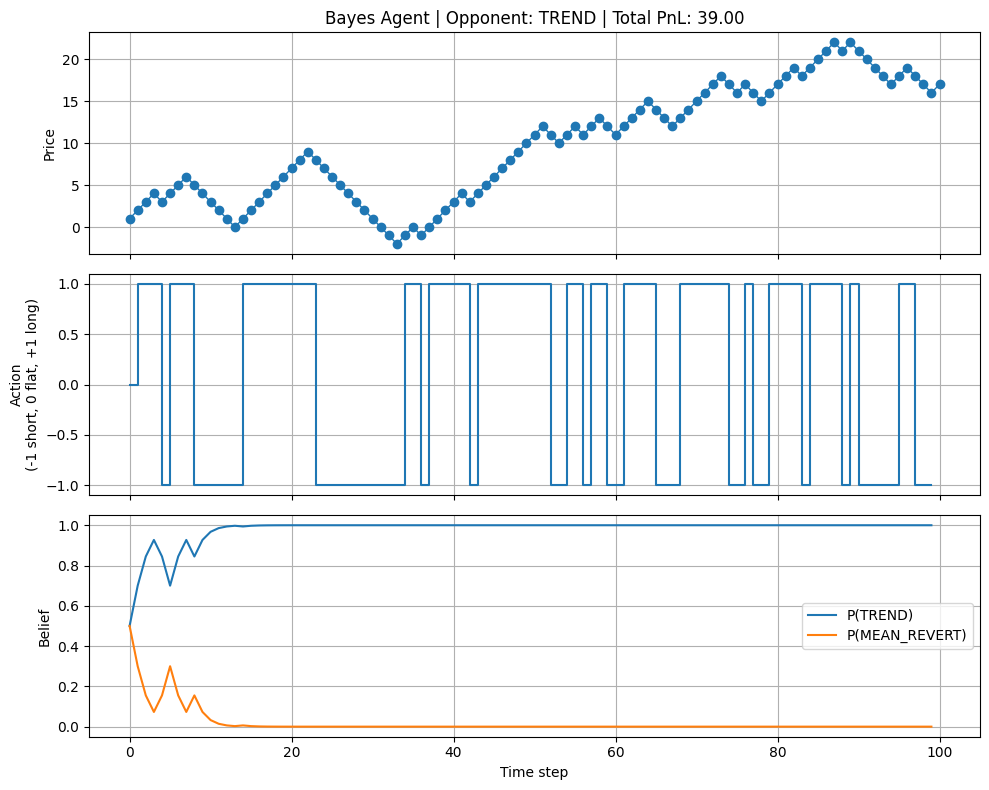

Bayesian Opponent Agent vs MEAN_REVERT:


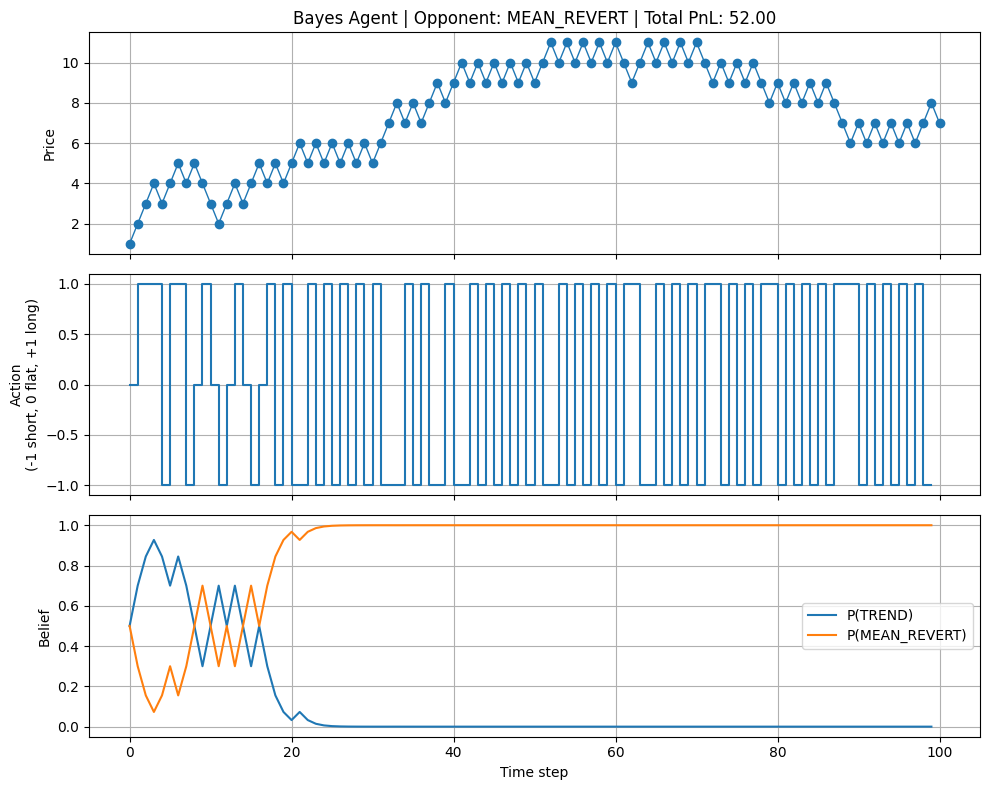

Episode PnL vs TREND:       39.00
Episode PnL vs MEAN_REVERT: 52.00


In [ ]:
# Create environment & agent
env = ToyMarketEnv(trend_prob=0.7, episode_len=100)
bayes_agent = BayesianOpponentAgent(trend_prob=0.7)

print("Bayesian Opponent Agent vs TREND:")
pnl_trend = run_episode(env, bayes_agent, OpponentType.TREND, title_prefix="Bayes Agent")

print("Bayesian Opponent Agent vs MEAN_REVERT:")
pnl_mean = run_episode(env, bayes_agent, OpponentType.MEAN_REVERT, title_prefix="Bayes Agent")

print(f"Episode PnL vs TREND:       {pnl_trend:.2f}")
print(f"Episode PnL vs MEAN_REVERT: {pnl_mean:.2f}")